In [1]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
sns.set_theme(style="whitegrid", palette="muted")

In [3]:
ORIGINAL_CSV_PATH = "oasis_cross-sectional.csv"
IMAGES_DIR = "oasis_images/oasis_preprocessed"
CLEAN_CSV_PATH = "oasis_validated.csv"

In [4]:
df = pd.read_csv(ORIGINAL_CSV_PATH)
print(f"dataset size: {len(df)} subjects")

dataset size: 436 subjects


In [5]:
df['target'] = (df['CDR'] > 0).astype(int)
df['target_label'] = df['target'].map({0: 'Healthy', 1: 'Impaired'})

df['mri_path'] = df['ID'].apply(lambda x: os.path.join(IMAGES_DIR, f"{x}_t1_masked.npy"))

print("Validating MRI file existence on disk...")
df['file_exists'] = df['mri_path'].apply(os.path.exists)

missing_files = len(df) - df['file_exists'].sum()
print(f"Files found: {df['file_exists'].sum()}")
print(f"Files missing: {missing_files}")

Validating MRI file existence on disk...
Files found: 436
Files missing: 0


In [6]:
df_clean = df[df['file_exists']].copy().reset_index(drop=True)
df_clean.to_csv(CLEAN_CSV_PATH, index=False)
print(f"\nSaved validated dataset to '{CLEAN_CSV_PATH}' with {len(df_clean)} records.")


Saved validated dataset to 'oasis_validated.csv' with 436 records.


C:\Users\Uman\AppData\Local\Temp\ipykernel_4552\3877631378.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df_clean, x='target_label', palette=['#2ca02c', '#d62728'])
C:\Users\Uman\AppData\Local\Temp\ipykernel_4552\3877631378.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean, x='target_label', y='Age', palette=['#2ca02c', '#d62728'])
C:\Users\Uman\AppData\Local\Temp\ipykernel_4552\3877631378.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean, x='target_label', y='Educ', palette=['#2ca02c', '#d

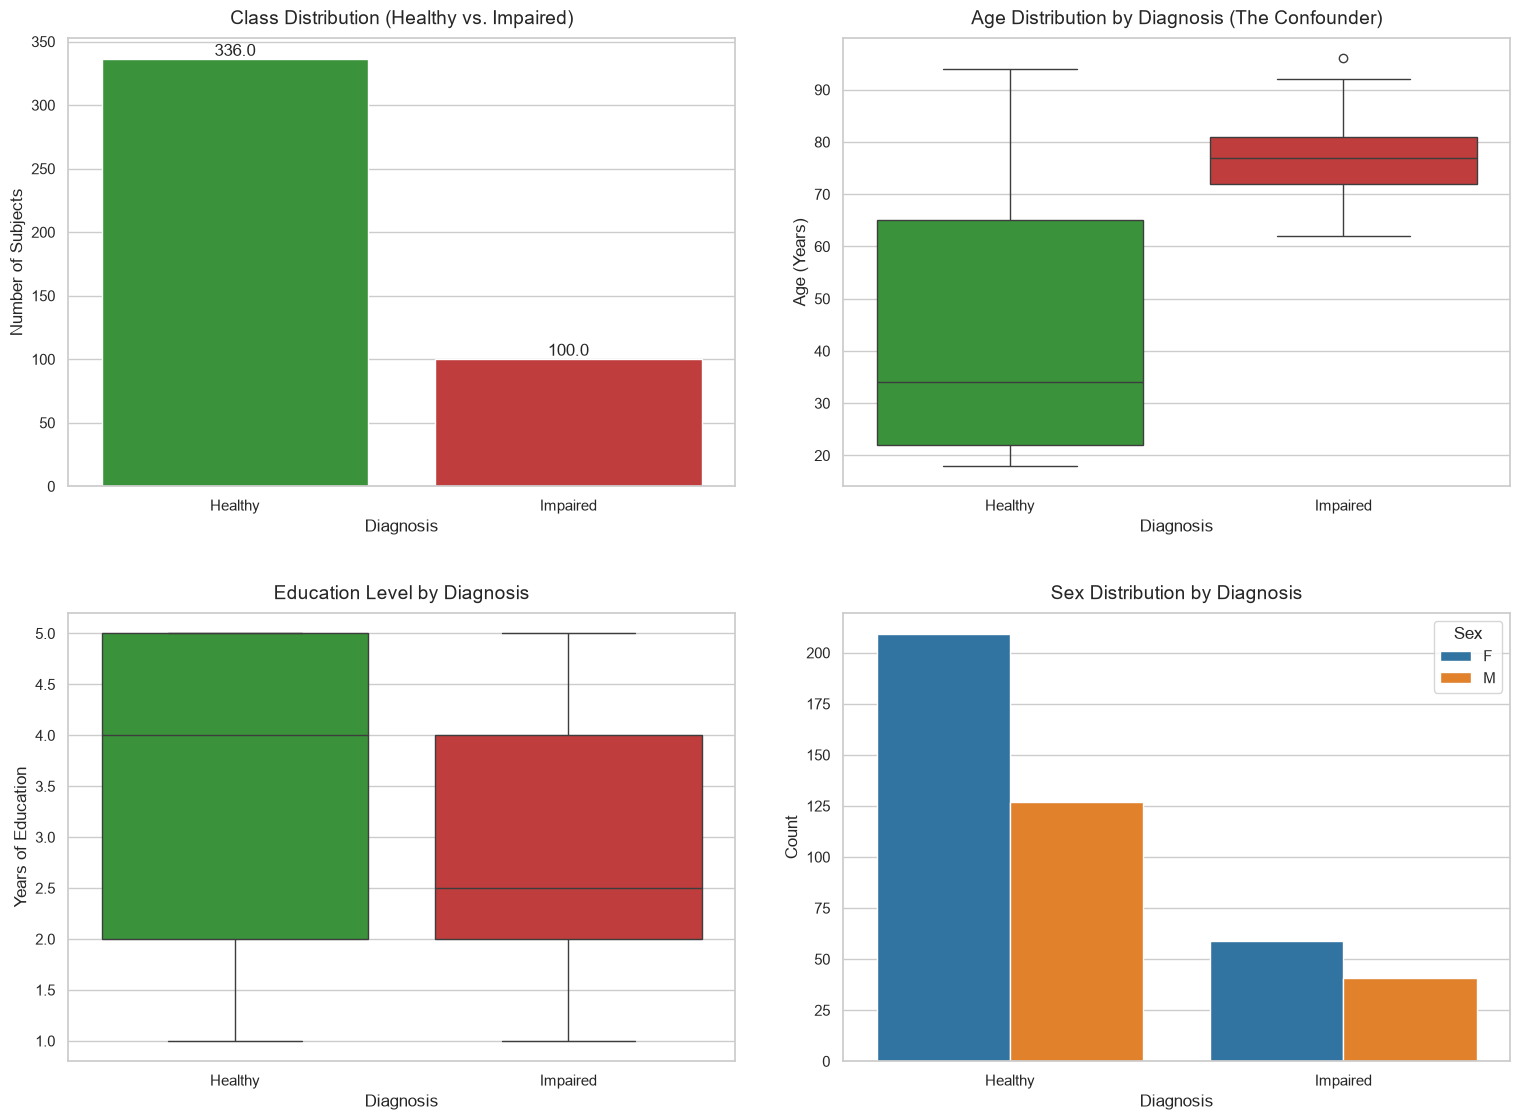

In [7]:
plt.figure(figsize=(16, 12))

plt.subplot(2, 2, 1)
ax = sns.countplot(data=df_clean, x='target_label', palette=['#2ca02c', '#d62728'])
plt.title("Class Distribution (Healthy vs. Impaired)", fontsize=14, pad=10)
plt.xlabel("Diagnosis")
plt.ylabel("Number of Subjects")
for p in ax.patches:
    ax.annotate(f'{p.get_height()}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=12)

plt.subplot(2, 2, 2)
sns.boxplot(data=df_clean, x='target_label', y='Age', palette=['#2ca02c', '#d62728'])
plt.title("Age Distribution by Diagnosis (The Confounder)", fontsize=14, pad=10)
plt.xlabel("Diagnosis")
plt.ylabel("Age (Years)")

plt.subplot(2, 2, 3)
sns.boxplot(data=df_clean, x='target_label', y='Educ', palette=['#2ca02c', '#d62728'])
plt.title("Education Level by Diagnosis", fontsize=14, pad=10)
plt.xlabel("Diagnosis")
plt.ylabel("Years of Education")

plt.subplot(2, 2, 4)
sns.countplot(data=df_clean, x='target_label', hue='M/F', palette=['#1f77b4', '#ff7f0e'])
plt.title("Sex Distribution by Diagnosis", fontsize=14, pad=10)
plt.xlabel("Diagnosis")
plt.ylabel("Count")
plt.legend(title="Sex")

plt.tight_layout(pad=3.0)
plt.show()

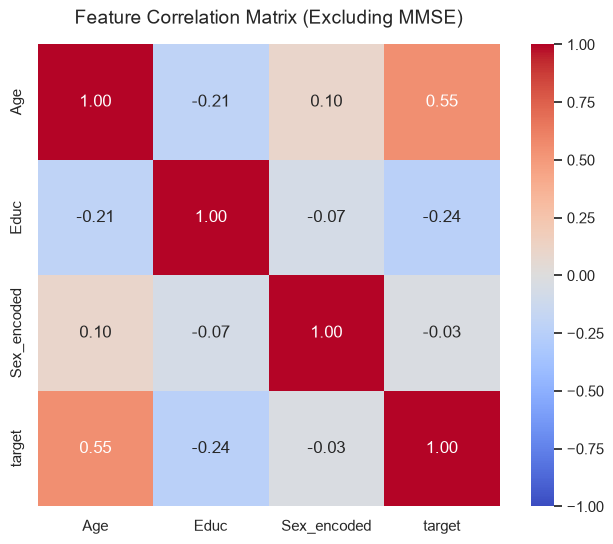

AGE DEMOGRAPHICS SUMMARY
              count       mean        std   min   max
target_label                                         
Healthy       336.0  43.797619  23.754103  18.0  94.0
Impaired      100.0  76.760000   7.119641  62.0  96.0


In [8]:
df_clean['Sex_encoded'] = df_clean['M/F'].map({'M': 0, 'F': 1})

features_to_correlate = ['Age', 'Educ', 'Sex_encoded', 'target']
corr_matrix = df_clean[features_to_correlate].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", vmin=-1, vmax=1, square=True)
plt.title("Feature Correlation Matrix (Excluding MMSE)", fontsize=14, pad=15)
plt.show()

print("AGE DEMOGRAPHICS SUMMARY")
print(df_clean.groupby('target_label')['Age'].describe()[['count', 'mean', 'std', 'min', 'max']])

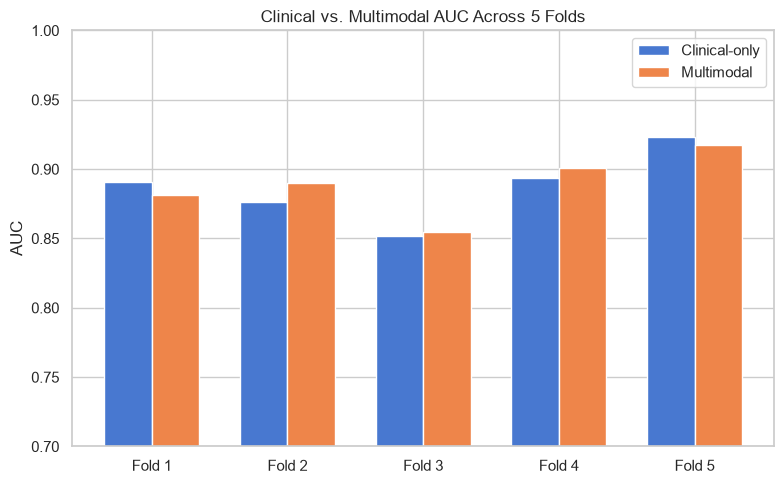

In [9]:
import matplotlib.pyplot as plt
import numpy as np

folds = ['Fold 1', 'Fold 2', 'Fold 3', 'Fold 4', 'Fold 5']
clinical_auc = [0.8904, 0.8761, 0.8519, 0.8937, 0.9235]
multimodal_auc = [0.8816, 0.8903, 0.8545, 0.9011, 0.9175]

x = np.arange(len(folds))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(x - width/2, clinical_auc, width, label='Clinical-only')
ax.bar(x + width/2, multimodal_auc, width, label='Multimodal')

ax.set_ylabel('AUC')
ax.set_title('Clinical vs. Multimodal AUC Across 5 Folds')
ax.set_xticks(x)
ax.set_xticklabels(folds)
ax.set_ylim(0.7, 1.0)
ax.legend()
plt.tight_layout()
plt.savefig('fold_comparison.png', dpi=150)
plt.show()